In [ ]:
!pip install py3plex --quiet

In [ ]:
from py3plex.core import multinet
from py3plex.dsl import Q, L

In [ ]:
import pandas as pd

# Módulo Q y L de py3plex

En este notebook veremos el módulo Q, de la libreria py3plex.

Q es, en esencia, un Lenguaje de Dominio Específico (DSL) (*Domain-Specific Language*) para consultar y analizar redes multicapa utilizando una sintaxis similar a SQL.

Su principal uso es filtrar nodos y aristas, calcular métricas de redes y realizar análisis complejos mediante consultas sencillas y legibles.



In [ ]:
network = multinet.multi_layer_network(directed=False)
#Enlaces
network.add_edges([
    #Capa 'coauthor'
    ['Alice', 'coauthor', 'Bob', 'coauthor', 1],
    ['Bob', 'coauthor', 'Dave', 'coauthor', 1],
    ['Bob', 'coauthor', 'Eve', 'coauthor', 1],
    ['Eve', 'coauthor', 'Frank', 'coauthor', 1],
    ['Alice', 'coauthor', 'Grace', 'coauthor', 1],
    ['Grace', 'coauthor', 'Heidi', 'coauthor', 1],
    ['Frank', 'coauthor', 'Ivan', 'coauthor', 1],
    #Capa 'twitter'
    ['Alice', 'twitter', 'Carol', 'twitter', 1],
    ['Carol', 'twitter', 'Dave', 'twitter', 1],
    ['Eve', 'twitter', 'Ivan', 'twitter', 1],
    ['Ivan', 'twitter', 'Judy', 'twitter', 1],
    ['Alice', 'twitter', 'Judy', 'twitter', 1],
    ['Frank', 'twitter', 'Bob', 'twitter', 1],
    ['Heidi', 'twitter', 'Carol', 'twitter', 1]
], input_type="list")

network.summary()

{'Number of layers': 2,
 'Nodes': 17,
 'Edges': 14,
 'Mean degree': np.float64(1.6470588235294117),
 'CC': 3,
 'Mode': 'multilayer',
 'Replica model': 'partial',
 'Interlayer coupling': 'none',
 'Directed': False,
 'Weighted': True}

¿Por qué usar Q si se puede con ciclos `for`?

In [ ]:
#Método tradicional
import networkx as nx

high_degree_nodes = []
for node in network.get_nodes():
  if node[1] == 'social': # Check layer
    degree = network.core_network.degree(node)
    if degree > 5:
      high_degree_nodes.append(node)
# Compute centrality for filtered nodes
G = network.core_network # NetworkX graph
centralities = nx.betweenness_centrality(G)
filtered_centralities = {node: centralities[node] for node in high_degree_nodes}
filtered_centralities

{}

In [ ]:
#Usando DSL
from py3plex.dsl import execute_query

result = execute_query(network,
'SELECT nodes WHERE layer="social" AND degree > 5 '
'COMPUTE betweenness_centrality'
)
print(result['nodes'])

2026-03-09 18:59:42 - py3plex.dsl_legacy - INFO - Executing DSL query: SELECT nodes WHERE layer="social" AND degree > 5 COMPUTE betweenness_centrality
INFO:py3plex.dsl_legacy:Executing DSL query: SELECT nodes WHERE layer="social" AND degree > 5 COMPUTE betweenness_centrality
2026-03-09 18:59:42 - py3plex.dsl_legacy - INFO - Query returned 0 nodes
INFO:py3plex.dsl_legacy:Query returned 0 nodes


[]


In [ ]:
#Nodos de una capa especifica
result = (
Q.nodes()
.from_layers(L["twitter"])
.execute(network)
)
print(result.to_pandas())

      id    layer
0  Alice  twitter
1  Carol  twitter
2   Dave  twitter
3    Eve  twitter
4   Ivan  twitter
5   Judy  twitter
6  Frank  twitter
7    Bob  twitter
8  Heidi  twitter


In [ ]:
#Nodos de todas las capas
result = (
Q.nodes()
.from_layers(L["*"])
.execute(network)
)
print(result.to_pandas())

       id     layer
0   Alice  coauthor
1     Bob  coauthor
2    Dave  coauthor
3     Eve  coauthor
4   Frank  coauthor
5   Grace  coauthor
6   Heidi  coauthor
7    Ivan  coauthor
8   Alice   twitter
9   Carol   twitter
10   Dave   twitter
11    Eve   twitter
12   Ivan   twitter
13   Judy   twitter
14  Frank   twitter
15    Bob   twitter
16  Heidi   twitter


In [ ]:
#Nodos con gran grado en la capa coauthor
result = (
Q.nodes()
.from_layers(L["coauthor"])
.where(degree__gt=1) #grado mayor a 1
.compute("betweenness_centrality", "pagerank")
.order_by("-betweenness_centrality")
.limit(5)
.execute(network)
)

df = result.to_pandas()
df.head()

,id,layer,betweenness_centrality,pagerank
0,Bob,coauthor,0.666667,0.239055
1,Alice,coauthor,0.500000,0.245945
2,Eve,coauthor,0.500000,0.245945
3,Frank,coauthor,0.000000,0.134527
4,Grace,coauthor,0.000000,0.134527


Algunas características de Q:

- Sintaxis similar a SQL
- Álgebra de capas (`L["social"] + L["work"] - L["bots"]`)
- Type-safe Python builder API: El código está diseñado con "pistas de tipado"
- Se puede exportar una consulta a pandas, CSV, JSON o como objeto de NetwokX
- *EXPLAIN mode for query optimization*: Si se usa `.explain()` no se ejecuta la consulta, mas bien explica que hará la consulta si se ejecuta.

Errores de los que avisa el autor:

La ambiguedad de términos como "grado". Hay 3 grados:
- Grado intra-capa
- Grado inter-capa
- Grado agregado (intra + inter)

Por defecto, py3plex calcula el grado agregado

In [ ]:
#Grado por capa
result = Q.nodes().compute("degree").execute(network)
df = result.to_pandas()
df.head(-1)

,id,layer,degree
0,Alice,coauthor,2
1,Bob,coauthor,3
2,Dave,coauthor,1
3,Eve,coauthor,2
4,Frank,coauthor,2
5,Grace,coauthor,2
6,Heidi,coauthor,1
7,Ivan,coauthor,1
8,Alice,twitter,2
9,Carol,twitter,3


In [ ]:
#intra-capa
result = (
Q.nodes()
.per_layer() #por cada capa...
.compute("degree") #grado, pero x capa
.execute(network)
)
df = result.to_pandas()
df.head(-1)

,id,layer,degree
0,Alice,coauthor,2
1,Bob,coauthor,3
2,Dave,coauthor,1
3,Eve,coauthor,2
4,Frank,coauthor,2
5,Grace,coauthor,2
6,Heidi,coauthor,1
7,Ivan,coauthor,1
8,Alice,twitter,2
9,Carol,twitter,3


In [ ]:
#Grado en una capa especifica
result = (
Q.nodes()
.from_layers(L["coauthor"]) #capa coautor, todas con L["*"]
.compute("degree")
.execute(network)
)
df = result.to_pandas()
df.head(-1)

,id,layer,degree
0,Alice,coauthor,2
1,Bob,coauthor,3
2,Dave,coauthor,1
3,Eve,coauthor,2
4,Frank,coauthor,2
5,Grace,coauthor,2
6,Heidi,coauthor,1


In [ ]:
from py3plex.core import multinet
from py3plex.dsl import Q, L

network_big = multinet.multi_layer_network()
edges = []

#Estrellas de 1 sola capa, grado 15, pero en una sola capa
for i in range(15):
    edges.append(["Genio_Ermitaño", "academica", f"Becario_{i}", "academica", 1])
    edges.append(["Influencer_Local", "social", f"Fan_{i}", "social", 1])
    edges.append(["Gerente_Micromanagement", "corporativa", f"Empleado_{i}", "corporativa", 1])

#Lideres, grado 10, pero dominan en 2 capas distintas.
for i in range(10):
    edges.append(["Dra_Directora", "academica", f"Investigador_{i}", "academica", 1])
    edges.append(["Dra_Directora", "corporativa", f"Jefe_Depto_{i}", "corporativa", 1])

    edges.append(["Lider_Sindical", "social", f"Compañero_{i}", "social", 1])
    edges.append(["Lider_Sindical", "corporativa", f"Administrativo_{i}", "corporativa", 1])

    edges.append(["Profesor_Carismatico", "academica", f"Estudiante_{i}", "academica", 1])
    edges.append(["Profesor_Carismatico", "social", f"Amigo_Bar_{i}", "social", 1])

#Relleno
for j in range(3):
    for i in range(5):
         edges.append([f"Mando_Medio_Acad_{j}", "academica", f"Auxiliar_A_{j}_{i}", "academica", 1])
         edges.append([f"Mando_Medio_Soc_{j}", "social", f"Auxiliar_S_{j}_{i}", "social", 1])
         edges.append([f"Mando_Medio_Corp_{j}", "corporativa", f"Auxiliar_C_{j}_{i}", "corporativa", 1])

network_big.add_edges(edges, input_type="list")
print(network_big.summary())

{'Number of layers': 3, 'Nodes': 168, 'Edges': 150, 'Mean degree': np.float64(1.7857142857142858), 'CC': 18, 'Mode': 'multilayer', 'Replica model': 'partial', 'Interlayer coupling': 'none', 'Directed': True, 'Weighted': True}


In [ ]:
#Top nodos por grado
result = (
Q.nodes() #nodos
.per_layer() #por capa
.top_k(6, "degree") #top 6 nodos por grado
.end_grouping() #eliminamos el "por capa"
.coverage(mode="at_least", k=2) #Condicion: top 4 en al menos 2 capas diferentes
.execute(network_big) #sobre la red "network_big"
)
df = result.to_pandas()
df.head(-1)

,id,layer,degree
0,Dra_Directora,academica,10
1,Profesor_Carismatico,academica,10
2,Dra_Directora,corporativa,10
3,Lider_Sindical,corporativa,10
4,Lider_Sindical,social,10


In [ ]:
#top nodos por grado
result = (
Q.nodes()
.per_layer()
.top_k(2, "degree") #ser top 2...
.end_grouping()
.coverage(mode="fraction", p=0.6) #En al menos el 60% de las capas
.execute(network_big)
)
df = result.to_pandas()
df.head(-1)

,id,layer,degree
0,Profesor_Carismatico,academica,10


In [ ]:
result_before = (
Q.nodes()
.per_layer()
.top_k(20, "degree")
.end_grouping()
.execute(network_big)
)
print(f"Before coverage: {result_before.count} nodes")
#Top 20 de cada capa (social, academica, corporativa)

result_after = (
Q.nodes()
.per_layer()
.top_k(20, "degree")
.end_grouping()
.coverage(mode="all") #En todas las capas ser top 20
.execute(network_big)
)
print(f"After coverage: {result_after.count} nodes")
#No hay ningun nodo que sea top 20 en todas las capas (pues hay unos que existen solo en 2 y otros que tienen poco grado en todas)

Before coverage: 60 nodes
After coverage: 0 nodes


In [ ]:
from py3plex.dsl import Q, L

#Tamaño de cada capa
for layer in network.layers:
  count = Q.nodes().from_layers(L[layer]).execute(network).count
  print(f"{layer}: {count} nodes")

#Ver si hay nodos aislados
isolated = Q.nodes().where(degree=0).execute(network)
if isolated.count > 0:
  print(f"Warning: {isolated.count} isolated nodes")

#ver si hay hubs, y si si, si hacen sentido
hubs = (
Q.nodes()
.where(degree__gt=20)
.compute("degree")
.execute(network)
)
print(f"Hubs (degree > 20): {hubs.count}")

coauthor: 8 nodes
twitter: 9 nodes
Hubs (degree > 20): 0


In [ ]:
from py3plex.dsl import Q, L
#Nodos con alto grado en capas especificas
result = (
Q.nodes()
.from_layers(L["social"] + L["academica"])
.where(degree__gt=5) #gt_ greater than >
.execute(network_big)
)
# Extract subgraph for visualization
high_degree_nodes = list(result.nodes)
subgraph = network_big.core_network.subgraph(high_degree_nodes)
subgraph.nodes()

NodeView((('Genio_Ermitaño', 'academica'), ('Lider_Sindical', 'social'), ('Profesor_Carismatico', 'academica'), ('Profesor_Carismatico', 'social'), ('Influencer_Local', 'social'), ('Dra_Directora', 'academica')))

# Álgebra sobre capas

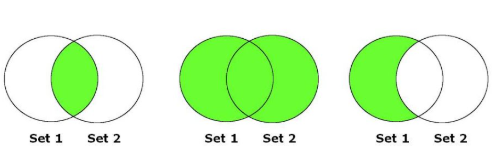

In [ ]:
from py3plex.dsl import Q, L

#Intersection: nodes in both social AND work
Q.nodes().from_layers(L["social"] & L["work"])
#Union: nodes in social OR work
Q.nodes().from_layers(L["social"] + L["work"])
#Difference: nodes in social but NOT bots
Q.nodes().from_layers(L["social"] - L["bots"])

#Complex: (social OR work) - bots
Q.nodes().from_layers(L["social"] + L["work"] - L["bots"])

QueryBuilder(target=nodes)

# Métricas

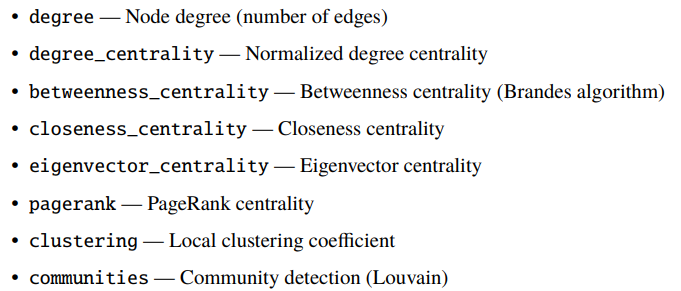

Se pueden estas con NetworkX: `network.core_network with any nx.*_centrality function`

• Katz centrality — Weighted count of walks (influence via connections)

• Load centrality — Traffic load through each node

• Harmonic centrality — Average inverse distance to all nodes

• Current flow betweenness — Betweenness based on electrical current flow

• Percolation centrality — Importance during network cascades

• Subgraph centrality — Based on counting closed walks

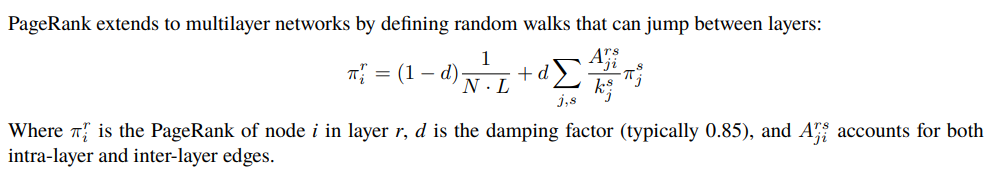

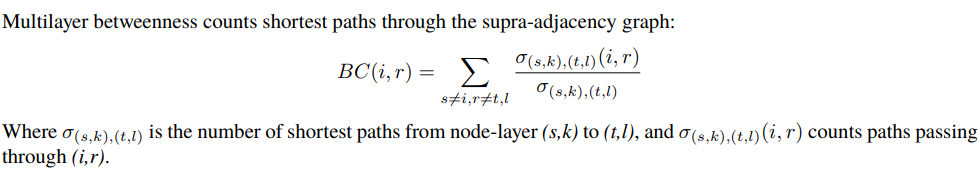

In [ ]:
from py3plex.dsl import Q, L

In [ ]:
#Crear una red multiplex no dirigida
net_plex = multinet.multi_layer_network(network_type='multiplex', directed=False)

#Añadir nodos
net_plex.add_nodes([
    {'source': 'Daniel', 'type': 'LinkedIn'}, #Nodo Daniel, capa LinkedIn
    {'source': 'Eduardo', 'type': 'LinkedIn'}, #Nodo Eduardo, capa LinkedIn
    {'source': 'Bibiana', 'type': 'LinkedIn'}, #Nodo Bibiana, capa LinkedIn
    {'source': 'Bibiana', 'type': 'email'}, #Nodo Bibiana, capa email
    {'source': 'Daniel', 'type': 'email'}, #Nodo Daniel, capa email
    {'source': 'Eduardo', 'type': 'email'}, #Nodo Eduardo, capa email
])

#Añadir enlaces
net_plex.add_edges([
    #Intra-capa
    {'source': 'Daniel', 'target': 'Eduardo',
     'source_type': 'LinkedIn', 'target_type': 'LinkedIn',
     'weight': 1},

    {'source': 'Eduardo', 'target': 'Bibiana',
     'source_type': 'email', 'target_type': 'email',
     'weight': 1},

    {'source': 'Daniel', 'target': 'Bibiana',
     'source_type': 'email', 'target_type': 'email',
     'weight': 1},
])

print(net_plex)

<multi_layer_network: type=multiplex, directed=False, nodes=6, edges=3, layers=2>


In [ ]:
#Como no hay documentación, hay que ver que métricas tiene la libreria
try:
    Q.nodes().from_layers(L["*"]).compute("METRICA_INVALIDA").execute(net_plex)
except Exception as e:
    print(e)

Unknown measure 'METRICA_INVALIDA'.
Known measures: betweenness, betweenness_centrality, closeness, closeness_centrality, clustering, clustering_coefficient, communities, community, degree, degree_centrality, edge_betweenness, edge_betweenness_centrality, eigenvector, eigenvector_centrality, pagerank, triangles


In [ ]:
result = (
    Q.nodes()
     .from_layers(L["*"])
     .compute(
         "betweenness",
         "betweenness_centrality",
         "closeness",
         "closeness_centrality",
         "clustering",
         "clustering_coefficient",
         "communities",
         "community",
         "degree",
         "degree_centrality",
         "pagerank",
         "triangles"
     )
     .order_by("-pagerank")  #Ordenamos de mayor a menor por PageRank
     .execute(net_plex)
)

df = result.to_pandas()
df.head(6)

,id,layer,betweenness,betweenness_centrality,closeness,closeness_centrality,clustering,clustering_coefficient,communities,community,degree,degree_centrality,pagerank,triangles
0,Bibiana,email,0.1,0.1,0.400000,0.400000,0.0,0.0,1,1,2,0.4,0.283391,0.0
1,Daniel,LinkedIn,0.0,0.0,0.200000,0.200000,0.0,0.0,0,0,1,0.2,0.194175,0.0
2,Eduardo,LinkedIn,0.0,0.0,0.200000,0.200000,0.0,0.0,0,0,1,0.2,0.194175,0.0
3,Daniel,email,0.0,0.0,0.266667,0.266667,0.0,0.0,1,1,1,0.2,0.149566,0.0
4,Eduardo,email,0.0,0.0,0.266667,0.266667,0.0,0.0,1,1,1,0.2,0.149566,0.0
5,Bibiana,LinkedIn,0.0,0.0,0.000000,0.000000,NaN,NaN,-1,-1,0,0.0,0.029126,NaN


In [ ]:
#Metricas de enlaces
result_edges = (
    Q.edges()
     .from_layers(L["*"])
     .compute("edge_betweenness", "edge_betweenness_centrality")
     .order_by("-edge_betweenness")
     .execute(net_plex)
)

df_edges = result_edges.to_pandas()
df_edges.head(5)

,source,source_layer,target,target_layer,weight,edge_betweenness,edge_betweenness_centrality
0,Daniel,LinkedIn,Eduardo,LinkedIn,1.0,0.0,0.0
1,Bibiana,email,Eduardo,email,1.0,0.0,0.0
2,Bibiana,email,Daniel,email,1.0,0.0,0.0


`eigenvector` y `eigenvector_centrality` son solo para redes simples.

Se puede ordenar los resultados por 1 o mas metricas

In [ ]:
#Ascendente
Q.nodes().compute("degree").order_by("degree").execute(net_plex)
#Descendiente
Q.nodes().compute("degree").order_by("-degree").execute(net_plex)
#Varias metricas
Q.nodes().compute("degree").order_by("-degree", "betweenness").execute(net_plex)

QueryResult(
  target='nodes'
  count=6
  attributes=['degree', 'betweenness']
  provenance='unknown'
)

Iterar sobre una consulta

In [ ]:
result = Q.nodes().execute(net_plex)
for node in result:
  print(node)

('Daniel', 'LinkedIn')
('Eduardo', 'LinkedIn')
('Bibiana', 'LinkedIn')
('Bibiana', 'email')
('Daniel', 'email')
('Eduardo', 'email')


Contar los nodos que hubo en una consulta

In [ ]:
result = Q.nodes().where(degree__gt=5).execute(network)
print(f"Found {result.count} nodes")

Found 0 nodes


Convertir a pandas

In [ ]:
df = result_edges.to_pandas()
df.head()

,source,source_layer,target,target_layer,weight,edge_betweenness,edge_betweenness_centrality
0,Daniel,LinkedIn,Eduardo,LinkedIn,1.0,0.0,0.0
1,Bibiana,email,Eduardo,email,1.0,0.0,0.0
2,Bibiana,email,Daniel,email,1.0,0.0,0.0


# Algoritmos de Comunidades

 Louvain: Optimización rápida de la modularidad, **O(n log n)**. Optimo para redes con 100-100K nodos.

 Optimización rápida de la modularidad: Métrica de -1 a 1 que mide la densidad de las aristas (conexiones) dentro de las comunidades en comparación con las aristas fuera de ellas. Se busca maximizar el valor.

> "Una buena división de una red en comunidades no es simplemente una en la que hay pocos enlaces entre comunidades; es una en la que hay **menos enlaces de los esperados** entre comunidades.
>
> * Si el número de enlaces entre dos grupos es solo el que uno esperaría con base en el azar, entonces pocos observadores reflexivos afirmarían que esto constituye evidencia de una estructura de comunidades significativa.
> * Por otro lado, si el número de enlaces entre grupos es **significativamente menor del que esperamos por azar**, o equivalentemente si el número dentro de los grupos es significativamente mayor, entonces es razonable concluir que algo interesante está sucediendo."
>
> — M. E.J. Newman

In [ ]:
from py3plex.algorithms.community_detection import community_louvain

#Aplana la capa (no distingue de inter a intracapa)
#Puede separar a una persona en 2 grupos (Alice en Comunidad 0 y Comunidad 2)
communities = community_louvain.best_partition(network.core_network)

for node, comm_id in communities.items():
  print(f"Node {node} -> Community {comm_id}")

Node ('Alice', 'coauthor') -> Community 0
Node ('Bob', 'coauthor') -> Community 0
Node ('Dave', 'coauthor') -> Community 0
Node ('Eve', 'coauthor') -> Community 1
Node ('Frank', 'coauthor') -> Community 1
Node ('Grace', 'coauthor') -> Community 0
Node ('Heidi', 'coauthor') -> Community 0
Node ('Ivan', 'coauthor') -> Community 1
Node ('Alice', 'twitter') -> Community 2
Node ('Carol', 'twitter') -> Community 3
Node ('Dave', 'twitter') -> Community 3
Node ('Eve', 'twitter') -> Community 2
Node ('Ivan', 'twitter') -> Community 2
Node ('Judy', 'twitter') -> Community 2
Node ('Frank', 'twitter') -> Community 4
Node ('Bob', 'twitter') -> Community 4
Node ('Heidi', 'twitter') -> Community 3


Infomap: Detección basada en flujo mediante dinámica de recorrido aleatorio.

Consideraciones:
- No es licencia MIT, es AGPLv3, lo que obliga a volver todo el código de libre acceso (*open source*).
- Si no lo necesitas especificamente, el autor recomienda usar Louvian o  Label Propagation por eficiencia y simplicidad.
- Infomap tiende a encontrar comunidades más pequeñas y finas que Louvain (es capaz de detectar grupos muy pequeños y específicos que Louvain ignoraría por completo pues Louvain tiende a juntar comunidades pequeñas en una sola grande porque matemáticamente eso aumenta la modularidad.)

In [ ]:
!pip install py3plex[infomap] --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.2 MB/s eta 0:00:00


In [ ]:
import infomap
from collections import defaultdict

#Mapeo de nombres a números y viceversa
G = network.core_network
#encoder
node_to_id = {node: i for i, node in enumerate(G.nodes())}
#decoder
id_to_node = {i: node for node, i in node_to_id.items()}

#Configurar Infomap
# --two-level busca comunidades normales, --directed la red fuera
im = infomap.Infomap("--two-level --silent")


for u, v, data in G.edges(data=True):
    u_int = node_to_id[u]
    v_int = node_to_id[v]
    w = float(data.get('weight', 1.0))
    #Pasamos: (int, int, float)
    im.add_link(u_int, v_int, w)

im.run()

#Decodificar las comunidades
communities = {}
for node in im.tree:
    if node.is_leaf:
        original_node = id_to_node[node.node_id]
        communities[original_node] = node.module_id

#Agrupamos los nodos por su ID de comunidad
grupos = defaultdict(list)
for (nodo, capa), comm_id in communities.items():
    grupos[comm_id].append(f"{nodo} ({capa})")

for comm_id in sorted(grupos.keys()):
    miembros = ", ".join(grupos[comm_id])
    print(f"Comunidad {comm_id} [{len(grupos[comm_id])} nodos]:")
    print(f"  > {miembros}\n")

Comunidad 1 [7 nodos]:
  > Carol (twitter), Alice (twitter), Ivan (twitter), Judy (twitter), Eve (twitter), Dave (twitter), Heidi (twitter)

Comunidad 2 [5 nodos]:
  > Bob (coauthor), Alice (coauthor), Grace (coauthor), Dave (coauthor), Heidi (coauthor)

Comunidad 3 [3 nodos]:
  > Eve (coauthor), Frank (coauthor), Ivan (coauthor)

Comunidad 4 [2 nodos]:
  > Frank (twitter), Bob (twitter)



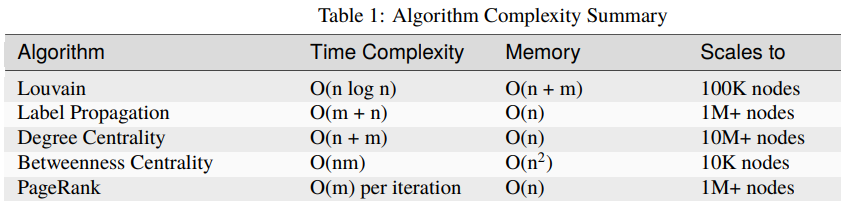